In [1]:
import os, sys, joblib, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from pathlib import Path
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                              recall_score, confusion_matrix)

try:
    _nb = globals().get('__vsc_ipynb_file__')
    if _nb:
        os.chdir(os.path.dirname(os.path.dirname(_nb)))
except Exception:
    pass

%load_ext autoreload
%autoreload 2
import config
%matplotlib inline

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.color': '#e0e0e0',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'font.size': 10,
})
print("CWD:", os.getcwd())



[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0

CWD: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
sys.path.insert(0, 'utils')
sys.path.insert(0, 'utils/model_training')
from model_utils import build_well_stratified_random_split, build_well_stratified_nfold_splits
from sklearn.preprocessing import LabelEncoder

def reconstruct_well_splits(y_full, well_ids_full, mask=None, n_splits=1, random_state=0):
    """Replays evaluate_outlier_filters' own mask -> rare-class-drop -> well-stratified-split
    procedure (utils/model_training/model_utils.py:863-916) exactly, so the returned test-set
    well_ids line up with the cached y_trues_/y_preds_AC_* arrays. mask=None means the
    outlier_filter=None case (no rows removed pre-split). n_splits=1 uses the same
    max(10%, n_wells) test_size floor evaluate_outlier_filters uses for its single-split
    case; n_splits>1 returns that many well-stratified CV folds.
    Returns a list of (y_values_fold, well_ids_fold) pairs, one per fold, in the same
    order as evaluate_outlier_filters' own `splits` list."""
    if mask is None:
        mask = np.ones(len(y_full), dtype=bool)
    y_m, w_m = y_full[mask], well_ids_full[mask]

    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    y_v, w_v = y_m[valid], w_m[valid]

    if n_splits == 1:
        n_wells = len(np.unique(w_v))
        test_size = max(len(y_v) * 0.10, n_wells) / len(y_v)
        splits = list(build_well_stratified_random_split(
            y_v, w_v, test_size=test_size, random_state=random_state).values())
    else:
        actual_splits = min(n_splits, len(np.unique(w_v)))
        splits = list(build_well_stratified_nfold_splits(
            y_v, w_v, n_splits=actual_splits, random_state=random_state).values())

    return [(y_v[test_idx], w_v[test_idx]) for _, test_idx in splits]

def remap_well_splits(well_ids_full, y_full, mask, global_splits):
    """Mirrors _remap_global_splits (utils/model_training/model_utils.py:710) plus the
    rare-class-drop step inside evaluate_outlier_filters, for the cv_splits-supplied path
    used by 04_cross_dataset_training.py's kfold/lofo modes -- where the split is computed
    ONCE on the full (unmasked) pool and then masked/remapped per outlier filter, rather
    than split fresh per filter like reconstruct_well_splits above.
    global_splits: dict or list of (train_idx, test_idx) pairs in full-pool index space.
    Returns a dict/list (matching global_splits' own container type) of
    (y_values_fold, well_ids_fold) pairs."""
    kept_global = np.where(mask)[0]
    y_m, w_m = y_full[mask], well_ids_full[mask]
    unique_classes, class_counts = np.unique(y_m, return_counts=True)
    rare = unique_classes[class_counts < 2]
    valid = ~np.isin(y_m, rare)
    kept_global = kept_global[valid]
    y_v, w_v = y_m[valid], w_m[valid]
    pos_lookup = {g: i for i, g in enumerate(kept_global)}

    def _remap_one(test_idx):
        local_test = np.array([pos_lookup[g] for g in test_idx if g in pos_lookup], dtype=int)
        return y_v[local_test], w_v[local_test]

    if isinstance(global_splits, dict):
        return {k: _remap_one(test_idx) for k, (_, test_idx) in global_splits.items()}
    return [_remap_one(test_idx) for _, test_idx in global_splits]

def well_level_accuracy(y_trues_flat, preds_flat, well_ids_test):
    """Majority-votes each well's pixel predictions into one verdict; accuracy over wells.
    The true label per well should be unanimous (one well = one label) -- a mismatch
    there signals a split-reconstruction bug, not real label noise."""
    wells = np.unique(well_ids_test)
    n_true_mismatch = 0
    correct = 0
    for w in wells:
        m = well_ids_test == w
        true_vals = pd.Series(y_trues_flat[m])
        if true_vals.nunique() > 1:
            n_true_mismatch += 1
        true_label = true_vals.mode()[0]
        pred_label = pd.Series(preds_flat[m]).mode()[0]
        correct += int(true_label == pred_label)
    if n_true_mismatch:
        print(f"  [!] {n_true_mismatch} well(s) had a non-unanimous true label -- "
              f"split reconstruction likely mismatched training.")
    return correct / len(wells), len(wells)

def verified_well_ids(y_true_cached, folds, context=""):
    """folds: list of (y_values_fold, well_ids_fold) pairs (from reconstruct_well_splits /
    remap_well_splits), covering the same rows as y_true_cached once concatenated in fold
    order. Returns the concatenated well_ids only if the concatenated y-values match
    y_true_cached exactly (length AND values) -- otherwise warns and returns None, so a
    reconstruction bug never silently produces a wrong well_accuracy number."""
    if not folds:
        return None
    y_check = np.concatenate([y for y, _ in folds])
    well_ids = np.concatenate([w for _, w in folds])
    if len(y_check) != len(y_true_cached) or not np.array_equal(y_check, y_true_cached):
        print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
        return None
    return well_ids

def verified_well_folds(cached_y_folds, folds, context=""):
    """Per-fold version of verified_well_ids -- for compute_fold_accuracy_stats, which needs
    one well_ids array per fold (not pooled) to compute a mean/std across folds. Returns a
    list of well_ids arrays (same fold order as cached_y_folds) only if every fold's
    y-values match exactly; otherwise warns and returns None."""
    if folds is None or len(folds) != len(cached_y_folds):
        print(f"  [!] well-id reconstruction mismatch ({context}: fold count) -- skipping well_accuracy.")
        return None
    out = []
    for (y_v, w_v), yt in zip(folds, cached_y_folds):
        if len(y_v) != len(yt) or not np.array_equal(y_v, yt):
            print(f"  [!] well-id reconstruction mismatch ({context}) -- skipping well_accuracy.")
            return None
        out.append(w_v)
    return out


In [3]:
FAMILIES = [
            'cnn_gru_dual', 
            'cnn_gru_dual_attn_recon', 
            ]
# SC_LEVELS = [0, 1, 2, 3]
SC_LEVELS = [0]

MODEL_KEY = {
    (fam, 0): fam for fam in FAMILIES
}

MODELS = [MODEL_KEY[(fam, sc)] for sc in SC_LEVELS for fam in FAMILIES]
MODEL_TO_FAMILY = {MODEL_KEY[(fam, sc)]: fam for sc in SC_LEVELS for fam in FAMILIES}

# ── Paths ─────────────────────────────────────────────────────────────────────

EXP_FOLDER = config.FINAL_EXP_FOLDER

TARGET_FOLDERS = config.CROSS_DATASET_GROUPS['final_6_new']

def short_name(folder):
    m = re.search(r'DDM_0(\d)', folder)
    return f'Chip 0{m.group(1)}' if m else folder.split('_U_', 1)[1]

DATASET_NAMES = [short_name(f) for f in TARGET_FOLDERS]

# ── Labels ────────────────────────────────────────────────────────────────────
# Standard model naming, shared across every section of this notebook (RQ2, RQ3.1, RQ3.2)
# and mirrored verbatim in 0_LOFO_INSPECTION.ipynb -- the single source of truth for how a
# model key is displayed on any chart.
FAMILY_LABELS = {
    'cnn_gru_dual': 'CNN-BiGRU',
    'cnn_gru_dual_dann': 'CNN-BiGRU\n+ DANN',
    'cnn_gru_dual_supcon3': 'CNN-BiGRU\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_pc_recenter': 'CNN-BiGRU\n+ Latent Alignment',

    'cnn_gru_dual_attn_recon':   'CNN-BiGRU + Spatial Attn',
    'cnn_gru_dual_attn_recon_aug': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug',
    'cnn_gru_dual_attn_recon_dann': 'CNN-BiGRU + Spatial Attn\n+ DANN',
    'cnn_gru_dual_attn_recon_supcon3': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3)',
    'cnn_gru_dual_attn_recon_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Latent Alignment',

    'cnn_gru_dual_cosine_recon': 'CNN-BiGRU + Cosine Recon',
    'ccgd_arch_poc_st': 'CCGD-ST',

    'knn': 'kNN',
    'cnn_gru_dual_attn_recon_dann_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ DANN + Latent Alignment',
    'cnn_gru_dual_attn_recon_supcon3_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Contrastive Loss (SC3) + Latent Alignment',
    'cnn_gru_dual_attn_recon_aug_pc_recenter': 'CNN-BiGRU + Spatial Attn\n+ Temporal Aug + Latent Alignment',
}

# ── Colors ────────────────────────────────────────────────────────────────────
# dataviz-skill validated categorical palette, assigned in a `models`-list's order --
# shared by every grouped-bar-by-model chart in this notebook (RQ2 and RQ3.1 alike).
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100',
           '#e87ba4', '#008300', '#4a3aa7', '#e34948']

print(f"{len(MODELS)} models defined.")
print("  " + "\n  ".join(MODELS))


2 models defined.
  cnn_gru_dual
  cnn_gru_dual_attn_recon


In [4]:
TARGET_FOLDERS

['D20260827_E00_C00_F4500KHz_U_DDM_01_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_02_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_03_final_final',
 'D20260827_E00_C00_F4500KHz_U_DDM_04_final_final',
 'D20260825_E00_C00_F4500KHz_U_DDM_05_01',
 'D20260825_E00_C00_F4500KHz_U_DDM_06_02']

In [5]:
def compute_metrics(perf, model_key, well_ids=None):
    """Return dict with accuracy/f1/auc/sensitivity/specificity, or None if missing.
    well_ids (optional): array aligned 1:1 with concatenate(perf['y_trues_']) -- adds
    well_accuracy/n_wells (majority-vote-per-well accuracy) alongside the pixel-level
    metrics above. Pass an already length/value-verified array (see verified_well_ids)."""
    pred_k = f'y_preds_AC_{model_key}_'
    prob_k = f'y_probs_AC_{model_key}_'
    if pred_k not in perf:
        return None

    y_true  = np.concatenate(perf['y_trues_'])
    y_pred  = np.concatenate(perf[pred_k])
    y_probs = np.concatenate(perf[prob_k]) if prob_k in perf else None
    n_cls   = len(np.unique(y_true))

    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)

    if y_probs is not None and n_cls > 1:
        try:
            auc = roc_auc_score(y_true, y_probs, multi_class='ovr', average='macro')
        except Exception:
            auc = np.nan
    else:
        auc = np.nan

    # Specificity = TN/(TN+FP) per class, macro-averaged
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)

    out = {'accuracy': acc, 'f1': f1, 'auc': auc,
           'sensitivity': sens, 'specificity': float(np.mean(specs))}

    if well_ids is not None:
        well_acc, n_wells = well_level_accuracy(y_true, y_pred, well_ids)
        out['well_accuracy'] = well_acc
        out['n_wells'] = n_wells

    return out


In [6]:
def macro_f1_sens_spec(y_true, y_pred):
    """F1/sensitivity (recall) macro-averaged, plus specificity (TN/(TN+FP) per class,
    macro-averaged) -- the exact computation compute_metrics uses on a single pooled
    split, factored out so compute_fold_accuracy_stats/load_cv_accuracy can call it once
    per fold instead (giving a real mean/std across folds rather than one pooled value)."""
    n_cls = len(np.unique(y_true))
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    sens = recall_score(y_true, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    specs = []
    for i in range(n_cls):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - cm[i, :].sum() - fp
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0.0)
    return f1, sens, float(np.mean(specs))


# 1. RQ2: PER-FOLD OUTLIER-FILTER ABLATION (Ablation 6)

Reads `ablations/ablation6_chip_outlier_model_ablation_performances.joblib` per chip --
a separate 5-fold CV run (`ablation6_chip_outlier_model_ablation.py`, `ori_curve_sg_p4_norm`)
comparing 2 models (baseline, no outlier filter), distinct from RQ2's single-split `classification_performances.joblib` above.

In [7]:
ABL6_MODELS = ['cnn_gru_dual', 'cnn_gru_dual_attn_recon']
ABL6_CURVE_TYPE = 'sgp4_norm'
ABL6_FILTERS = [None]  # f_sngl_g13.sh's ablation6 run only trains the baseline (no filter)

print(f"{len(ABL6_MODELS)} models x {len(ABL6_FILTERS)} filters defined.")


2 models x 1 filters defined.


In [8]:
def compute_fold_accuracy_stats(perf, model_key, well_ids_folds=None):
    """Mean/std accuracy ACROSS folds (not pooled) -- matches ablation6_chip_outlier_model_ablation.py's
    own '86.85% ± 0.49%' log line exactly (utils/model_training/model_utils.py:2476-2486):
    one accuracy_score() per fold, then np.mean/np.std (ddof=0) across those fold-level numbers.
    F1/sensitivity/specificity get the same per-fold-then-mean/std treatment (via
    macro_f1_sens_spec), unlike compute_metrics' pooled versions of those three.
    well_ids_folds (optional): list of well_ids arrays, one per fold, same order/length as
    perf['y_trues_'] -- adds the well-level equivalent (well_accuracy_mean/std)."""
    pred_k = f'y_preds_AC_{model_key}_'
    if pred_k not in perf:
        return None
    fold_accs = [accuracy_score(yt, yp) for yt, yp in zip(perf['y_trues_'], perf[pred_k])]
    out = {'accuracy_mean': np.mean(fold_accs) * 100, 'accuracy_std': np.std(fold_accs) * 100}

    fold_f1s, fold_senss, fold_specs = [], [], []
    for yt, yp in zip(perf['y_trues_'], perf[pred_k]):
        f1, sens, spec = macro_f1_sens_spec(yt, yp)
        fold_f1s.append(f1); fold_senss.append(sens); fold_specs.append(spec)
    out['f1_mean'] = np.mean(fold_f1s) * 100;             out['f1_std'] = np.std(fold_f1s) * 100
    out['sensitivity_mean'] = np.mean(fold_senss) * 100;  out['sensitivity_std'] = np.std(fold_senss) * 100
    out['specificity_mean'] = np.mean(fold_specs) * 100;  out['specificity_std'] = np.std(fold_specs) * 100

    if well_ids_folds is not None:
        fold_well_accs = []
        for yt, yp, w in zip(perf['y_trues_'], perf[pred_k], well_ids_folds):
            wa, _ = well_level_accuracy(yt, yp, w)
            fold_well_accs.append(wa)
        out['well_accuracy_mean'] = np.mean(fold_well_accs) * 100
        out['well_accuracy_std'] = np.std(fold_well_accs) * 100
    return out


_ABL6_ARRAYS_CACHE = {}

def _abl6_training_arrays(exp_path):
    """y_full/well_ids_full/features_df exactly as ablation6_chip_outlier_model_ablation.py's
    run_one() derives them for ABL6_CURVE_TYPE, cached per exp_path (training_data is large
    and every filter for a given folder needs the same arrays)."""
    if exp_path in _ABL6_ARRAYS_CACHE:
        return _ABL6_ARRAYS_CACHE[exp_path]
    training_data = joblib.load(exp_path / config.TRAINING_DATA_PATH)
    dataset_name = list(training_data["dataset_name"])
    kinetic_features = training_data["kinetic_features"]
    Y_well = training_data["Y_well"]

    keep = [i for i, n in enumerate(dataset_name)
            if not n.startswith("avg_") and not n.startswith("original_fitted_stretched")]
    dataset_name = [dataset_name[i] for i in keep]
    kinetic_features = [kinetic_features[i] for i in keep]

    metadata_df = pd.DataFrame(training_data["metadata"])
    well_ids_full = (metadata_df["well_id"].values if "well_id" in metadata_df.columns
                      else np.array(Y_well).copy())

    label_mappings = config.get_label_mappings(exp_path)
    if exp_path.name in label_mappings:
        mapping = label_mappings[exp_path.name]
        Y_well = [mapping.get(w, w) for w in Y_well]
    y_full = LabelEncoder().fit_transform(Y_well)

    target_name = config.CURVE_TYPE_ALIASES.get(ABL6_CURVE_TYPE, ABL6_CURVE_TYPE)
    result = ((y_full, well_ids_full, kinetic_features[dataset_name.index(target_name)])
              if target_name in dataset_name else (None, None, None))
    _ABL6_ARRAYS_CACHE[exp_path] = result
    return result


def abl6_well_folds(exp_path, filt):
    y_full, well_ids_full, features_df = _abl6_training_arrays(exp_path)
    if y_full is None:
        return None
    if filt is None:
        mask = np.ones(len(y_full), dtype=bool)
    elif filt not in features_df.columns:
        return None
    else:
        mask = (features_df[filt] == 1).fillna(False).values
    return reconstruct_well_splits(y_full, well_ids_full, mask=mask, n_splits=5)


def load_ablation6_all():
    rows = []
    for folder in TARGET_FOLDERS:
        dataset = short_name(folder)
        exp_path = Path(EXP_FOLDER) / folder
        path = exp_path / 'ablations' / 'ablation6_chip_outlier_model_ablation_performances.joblib'
        if not path.exists():
            print(f'[WARN] missing {path}')
            continue
        data = joblib.load(path)
        for filt in ABL6_FILTERS:
            perf = data.get(filt)
            if perf is None:
                continue
            well_folds = abl6_well_folds(exp_path, filt)
            for model in ABL6_MODELS:
                m = compute_metrics(perf, model)
                if m is None:
                    continue
                # Prefer well_ids_test_ (see load_all's comment above) over replaying the split.
                saved_well_ids_folds = perf.get('well_ids_test_')
                if saved_well_ids_folds is not None:
                    well_ids_folds = saved_well_ids_folds
                elif well_folds is not None:
                    well_ids_folds = verified_well_folds(perf['y_trues_'], well_folds,
                                                         context=f'{folder}/{filt}/{model}')
                else:
                    well_ids_folds = None
                stats = compute_fold_accuracy_stats(perf, model, well_ids_folds=well_ids_folds)
                rows.append(dict(dataset=dataset, outlier_filter=filt, model=model, **stats, **m))
    return pd.DataFrame(rows)

abl6_df = load_ablation6_all()
print(f"Loaded {len(abl6_df)} rows  |  "
      f"{abl6_df.dataset.nunique()} datasets  "
      f"{abl6_df.outlier_filter.nunique(dropna=False)} filters  "
      f"{abl6_df.model.nunique()} models")
abl6_df.head(8)


[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_01_final_final/ablations/ablation6_chip_outlier_model_ablation_performances.joblib


[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_03_final_final/ablations/ablation6_chip_outlier_model_ablation_performances.joblib
[WARN] missing /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/D20260827_E00_C00_F4500KHz_U_DDM_04_final_final/ablations/ablation6_chip_outlier_model_ablation_performances.joblib


Loaded 5 rows  |  3 datasets  1 filters  2 models


,dataset,outlier_filter,model,accuracy_mean,accuracy_std,f1_mean,f1_std,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,well_accuracy_mean,well_accuracy_std,accuracy,f1,auc,sensitivity,specificity
0,Chip 02,None,cnn_gru_dual,87.967283,0.437577,84.917133,0.568043,84.642370,0.579360,97.492023,0.089534,100.0,0.0,0.879673,0.849167,0.982772,0.846424,0.974920
1,Chip 02,None,cnn_gru_dual_attn_recon,99.729519,0.317514,99.610999,0.480482,99.644644,0.456544,99.949237,0.058868,100.0,0.0,0.997295,0.996104,0.999971,0.996447,0.999492
2,Chip 05,None,cnn_gru_dual,85.884726,0.847164,84.652062,1.025488,84.425586,1.006892,97.040446,0.173237,100.0,0.0,0.858847,0.846556,0.982227,0.844260,0.970404
3,Chip 06,None,cnn_gru_dual,76.070975,0.447256,75.622086,0.532661,76.089426,0.593027,95.123302,0.095711,100.0,0.0,0.760709,0.756416,0.960000,0.760898,0.951233
4,Chip 06,None,cnn_gru_dual_attn_recon,98.933459,0.603100,98.908991,0.633567,98.873051,0.592280,99.780181,0.121736,100.0,0.0,0.989335,0.989087,0.999859,0.988730,0.997802


In [9]:
def plot_accuracy_by_model_abl6(df, models, filt=None, value_col='accuracy_mean', std_col='accuracy_std',
                                value_label=None, figsize=(6, 4)):
    """Grouped bar chart: x=dataset, one sub-bar per model (order = `models`) -- same layout as
    plot_accuracy_by_model, but sourced from abl6_df's 5-fold mean/std columns and restricted to
    one outlier_filter (default None/baseline) instead of one (prep, curve_type). Error bars =
    std across the 5 CV folds; pass value_col='well_accuracy_mean', std_col='well_accuracy_std'
    for majority-vote well-level accuracy instead of pixel-level."""
    filt_mask = df.outlier_filter.isna() if filt is None else (df.outlier_filter == filt)
    sub = df[filt_mask]
    datasets = DATASET_NAMES
    n_models = len(models)
    bar_w = 0.8 / n_models
    x = np.arange(len(datasets))
    ylabel = value_label or f'{value_col.replace("_mean", "").replace("_", " ").title()} (%)'

    fig, ax = plt.subplots(figsize=figsize)
    for mi, model in enumerate(models):
        ys, errs = [], []
        for ds in datasets:
            r = sub[(sub.dataset == ds) & (sub.model == model)]
            if r.empty:
                ys.append(np.nan); errs.append(np.nan)
            else:
                ys.append(r[value_col].iloc[0]); errs.append(r[std_col].iloc[0])
        ys, errs = np.array(ys), np.array(errs)

        offset = (mi - (n_models - 1) / 2) * bar_w
        ax.bar(x + offset, np.nan_to_num(ys, nan=0), yerr=np.nan_to_num(errs, nan=0),
               width=bar_w, color=PALETTE[mi % len(PALETTE)],
               label=FAMILY_LABELS.get(model, model),
               edgecolor='white', linewidth=0.8,
               capsize=3, error_kw=dict(elinewidth=0.8, ecolor='#3a3a3a'))
        for xi, yi, ei in zip(x + offset, ys, errs):
            if not np.isnan(yi):
                ax.text(xi, yi + ei + 1.5, f'{yi:.2f}\n±{ei:.2f}', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(datasets)
    ax.set_xlabel('Dataset')
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 108)
    ax.legend(fontsize=11, framealpha=0.9, loc='upper center',
              bbox_to_anchor=(0.5, -0.22), ncol=n_models)
    fig.tight_layout()
    plt.show()


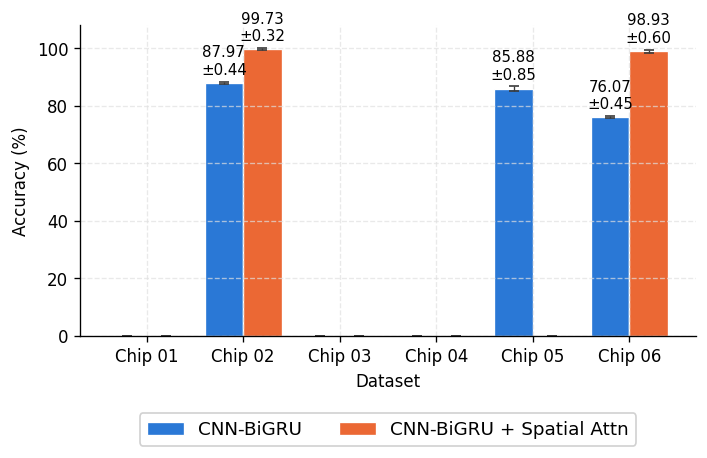

In [10]:
plot_accuracy_by_model_abl6(abl6_df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon']) #ABL6_MODELS)


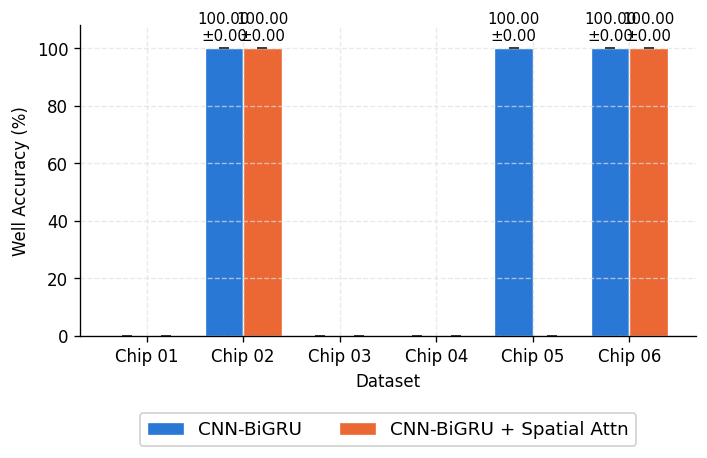

In [11]:
plot_accuracy_by_model_abl6(abl6_df, ['cnn_gru_dual', 'cnn_gru_dual_attn_recon'],
                             value_col='well_accuracy_mean', std_col='well_accuracy_std')

### LaTeX table -- Ablation6 baseline (no outlier filter), CNN-BiGRU vs. + Spatial Attn

Single table across all 4 datasets (rows), since only 2 models are compared: columns
are grouped by model (Accuracy, F1), each mean $\pm$ std across the 5 CV folds.


In [12]:
def build_abl6_latex_table(abl6_df, filt, models, model_labels, dataset_order,
                            caption, label, bold_model=None):
    filt_mask = abl6_df.outlier_filter.isna() if filt is None else (abl6_df.outlier_filter == filt)
    sub = abl6_df[filt_mask & abl6_df.model.isin(models)]

    metric_cols = [('accuracy_mean', 'accuracy_std'), ('f1_mean', 'f1_std'),
                   ('sensitivity_mean', 'sensitivity_std'), ('specificity_mean', 'specificity_std')]
    n_models = len(models)

    model_header = ' & '.join(
        f'\\multicolumn{{4}}{{c}}{{\\textbf{{{model_labels.get(m, m).replace(chr(10), " ")}}}}}'
        for m in models)
    model_cmid = ' '.join(f'\\cmidrule(lr){{{2 + 4*i}-{5 + 4*i}}}' for i in range(n_models))

    metric_row = ' & '.join(
        '\\textbf{Accuracy} & \\textbf{F1} & \\textbf{\\shortstack{Macro\\\\Sensitivity}} '
        '& \\textbf{\\shortstack{Macro\\\\Specificity}}'
        for _ in models)

    lines = [
        '\\begin{table}[htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{l' + 'rrrr' * n_models + '}',
        '    \\toprule',
        f'     & {model_header} \\\\',
        f'    {model_cmid}',
        f'    \\textbf{{Dataset}} & {metric_row} \\\\',
        '    \\midrule',
    ]
    for ds in dataset_order:
        row = sub[sub.dataset == ds]
        cells = []
        for m in models:
            r = row[row.model == m]
            for mean_col, std_col in metric_cols:
                if r.empty:
                    cells.append('--')
                    continue
                v = f"{r[mean_col].iloc[0]:.2f}\\% $\\pm$ {r[std_col].iloc[0]:.2f}\\%"
                if m == bold_model:
                    v = f'\\textbf{{{v}}}'
                cells.append(v)
        chip_label = ds
        lines.append(f'    {chip_label} & {" & ".join(cells)} \\\\')
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}']
    return '\n'.join(lines)


abl6_latex = build_abl6_latex_table(
    abl6_df, filt=None,
    models=['cnn_gru_dual', 'cnn_gru_dual_attn_recon'], model_labels=FAMILY_LABELS,
    dataset_order=DATASET_NAMES, bold_model='cnn_gru_dual_attn_recon',
    caption=('Intra-chip evaluation. Each chip is trained and evaluated independently '
             'under 5-fold cross-validation. Results are mean $\\pm$ standard deviation '
             'over folds.'),
    label='tab:abl6_baseline_acc_f1',
)
print(abl6_latex)


\begin{table}[htbp]
    \centering
    \caption{Intra-chip evaluation. Each chip is trained and evaluated independently under 5-fold cross-validation. Results are mean $\pm$ standard deviation over folds.}
    \label{tab:abl6_baseline_acc_f1}
    \small

    \resizebox{\textwidth}{!}{
    \begin{tabular}{lrrrrrrrr}
    \toprule
     & \multicolumn{4}{c}{\textbf{CNN-BiGRU}} & \multicolumn{4}{c}{\textbf{CNN-BiGRU + Spatial Attn}} \\
    \cmidrule(lr){2-5} \cmidrule(lr){6-9}
    \textbf{Dataset} & \textbf{Accuracy} & \textbf{F1} & \textbf{\shortstack{Macro\\Sensitivity}} & \textbf{\shortstack{Macro\\Specificity}} & \textbf{Accuracy} & \textbf{F1} & \textbf{\shortstack{Macro\\Sensitivity}} & \textbf{\shortstack{Macro\\Specificity}} \\
    \midrule
    Chip 01 & -- & -- & -- & -- & -- & -- & -- & -- \\
    Chip 02 & 87.97\% $\pm$ 0.44\% & 84.92\% $\pm$ 0.57\% & 84.64\% $\pm$ 0.58\% & 97.49\% $\pm$ 0.09\% & \textbf{99.73\% $\pm$ 0.32\%} & \textbf{99.61\% $\pm$ 0.48\%} & \textbf{99.64\% $\pm$

# 2. RQ3.1: CROSS VALIDATION

In [13]:
import importlib

# Reuse 06b's own results-file discovery instead of reimplementing it, so this
# section always matches what 06b_cross_dataset_prediction_report.py actually reads.
b06 = importlib.import_module("06b_cross_dataset_prediction_report")
# combine_group/build_nfold_splits/is_amplifying_mask -- reused as-is (not reimplemented)
# to reconstruct well_ids for well_accuracy below, so it stays exactly in sync with how
# 04_cross_dataset_training.py itself builds the kfold5 pool/splits/noamp_remove mask.
p04 = importlib.import_module("04_cross_dataset_training")

CV_MODE_STR    = "kfold5"
CV_FILTER      = "noamp_remove"
CV_CURVE_TYPES = ["ori_curve_sg_p4_norm"]
CV_CURVE_SHORT = {"ori_curve_sg_p4_norm": "sgp4_norm"}
CV_TRAIN_CENTER_FRAC = 0.5  # matches --train_center_frac on f_k5_g13.sh

def cv_group_dir(group_name):
    return Path(EXP_FOLDER) / "cross_dataset_cv" / group_name

def load_cv_results(group_name, curve_type, train_center_frac=CV_TRAIN_CENTER_FRAC):
    group_dir = cv_group_dir(group_name)
    print(group_dir)
    legacy_path = b06.find_results_path(group_dir, CV_MODE_STR, curve_type)
    print(legacy_path)
    return b06.load_partitioned(group_dir, CV_MODE_STR, curve_type, legacy_path=legacy_path,
                                train_center_frac=train_center_frac)


In [14]:
CV_MODELS = ['knn', 'cnn_gru_dual', 'cnn_gru_dual_attn_recon']

def _cv_well_folds(group_name, curve_type):
    """Test-set well_ids for every fold_x of this group/curve_type's kfold5 split, mirroring
    04_cross_dataset_training.py's kfold path exactly: combine_group() -> build_nfold_splits()
    on the full unmasked pool, then remap_well_splits() through the noamp_remove mask (the
    only outlier_filter this section evaluates, CV_FILTER). Returns None if well_ids weren't
    available for this group (missing pixel coords)."""
    exp_paths = [Path(EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[group_name]]
    combined = p04.combine_group(exp_paths, group_name, curve_type=curve_type)
    if combined is None:
        print(f"  [!] {group_name}/{curve_type}: combine_group() returned nothing -- well_accuracy skipped.")
        return None
    if combined["well_ids"] is None:
        print(f"  [!] {group_name}/{curve_type}: no pixel_row_idx/pixel_col_idx metadata (well_ids unavailable) -- well_accuracy skipped.")
        return None
    y_full = LabelEncoder().fit_transform(combined["Y_mapped"])
    cv_splits = p04.build_nfold_splits(y_full, well_ids=combined["well_ids"], n_splits=5)
    mask = (p04.is_amplifying_mask(combined["curves"]) if CV_FILTER == p04.NOAMP_FILTER_NAME
            else np.ones(len(y_full), dtype=bool))
    return remap_well_splits(combined["well_ids"], y_full, mask, cv_splits)


def load_cv_accuracy(group_indices=None, train_center_frac=CV_TRAIN_CENTER_FRAC):
    if group_indices is not None:
        groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
    else:
        groups = list(config.CROSS_DATASET_GROUPS)

    rows = []
    for group_name in groups:
        for curve_type in CV_CURVE_TYPES:
            lofo_results = load_cv_results(group_name, curve_type, train_center_frac=train_center_frac)
            if not lofo_results:
                print(f"[WARN] No results for group {group_name} / curve {curve_type}")
                continue
            fold_labels = sorted([k for k in lofo_results if k.startswith("fold_")],
                                  key=lambda s: int(s.split("_")[1]))

            # Prefer well_ids_test_ (saved directly by evaluate_outlier_filters -- see
            # utils/model_training/model_utils.py) over replaying the split. Only pay for
            # _cv_well_folds' group-pool rebuild if at least one fold still lacks the new key.
            _needs_legacy = any(
                lofo_results[fold].get(CV_FILTER, {}).get('well_ids_test_') is None
                for fold in fold_labels if lofo_results[fold].get(CV_FILTER) is not None
            )
            well_folds = None
            if _needs_legacy:
                try:
                    well_folds = _cv_well_folds(group_name, curve_type)
                except Exception as e:
                    print(f"  [!] {group_name}/{curve_type}: could not reconstruct well_ids ({e}) -- well_accuracy skipped.")
                    well_folds = None

            for fold in fold_labels:
                res_entry = lofo_results[fold].get(CV_FILTER)
                if res_entry is None:
                    continue
                y_true_full = np.concatenate(res_entry["y_trues_"])
                saved_well_ids = res_entry.get('well_ids_test_')
                if saved_well_ids is not None:
                    well_ids_test = np.concatenate(saved_well_ids)
                else:
                    well_ids_test = (verified_well_ids(y_true_full, [well_folds[fold]],
                                                       context=f'{group_name}/{curve_type}/{fold}')
                                     if well_folds is not None and fold in well_folds else None)
                for model in CV_MODELS:
                    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                    if preds_key is None or preds_key not in res_entry:
                        continue
                    y_pred = np.concatenate(res_entry[preds_key])
                    f1, sens, spec = macro_f1_sens_spec(y_true_full, y_pred)
                    row = dict(group=group_name, curve_type=CV_CURVE_SHORT.get(curve_type, curve_type),
                              fold=fold, model=model, family=MODEL_TO_FAMILY.get(model, model),
                              accuracy=accuracy_score(y_true_full, y_pred) * 100,
                              f1=f1 * 100, sensitivity=sens * 100, specificity=spec * 100,
                              n_test=len(y_true_full), well_accuracy=np.nan, n_wells=np.nan)
                    if well_ids_test is not None:
                        well_acc, n_wells = well_level_accuracy(y_true_full, y_pred, well_ids_test)
                        row["well_accuracy"] = well_acc * 100
                        row["n_wells"] = n_wells
                    rows.append(row)
    # Explicit columns so an empty result (e.g. train_center_frac results not
    # finished training yet) still has 'group'/'curve_type' etc. to groupby --
    # otherwise a 0-row, 0-column DataFrame KeyErrors every downstream groupby.
    return pd.DataFrame(rows, columns=['group', 'curve_type', 'fold', 'model', 'family', 'accuracy', 'f1', 'sensitivity', 'specificity', 'n_test', 'well_accuracy', 'n_wells'])

cv_df = load_cv_accuracy(group_indices=[list(config.CROSS_DATASET_GROUPS).index('final_6_new')])
if cv_df.empty:
    print("Loaded 0 rows -- no kfold5 CV results found for the requested groups/curve types.")
else:
    print(f"Loaded {len(cv_df)} rows  |  "
          f"{cv_df.group.nunique()} groups  "
          f"{cv_df.curve_type.nunique()} curve types  "
          f"{cv_df.fold.nunique()} folds  "
          f"{cv_df.model.nunique()} models")
cv_df.head(8)


/vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new
None
[WARN] No results for group final_6_new / curve ori_curve_sg_p4_norm
Loaded 0 rows -- no kfold5 CV results found for the requested groups/curve types.


,group,curve_type,fold,model,family,accuracy,f1,sensitivity,specificity,n_test,well_accuracy,n_wells


In [15]:
cv_expected = len(CV_MODELS)
cv_check = (cv_df.groupby(['group', 'curve_type', 'fold'])
              .size()
              .reset_index(name='n')
              .assign(expected=cv_expected, ok=lambda x: x.n == x.expected))
cv_missing = cv_check[~cv_check.ok]
if cv_missing.empty:
    print("All CV combinations fully populated.")
else:
    print("[!] Incomplete CV combinations (job likely still running):")
    display(cv_missing)


All CV combinations fully populated.


In [16]:
def plot_grouped_bar_by_model(df, x_col, x_order, models, model_labels,
                               value_col='accuracy', value_label=None, xlabel='', title='', figsize=(10, 6), plot_fold=True, plot_summary=True, show_std=True):

    n_models = len(models)
    ylabel = value_label or f'{value_col.replace("_", " ").title()} (%)'

    if plot_fold:
        bar_w = 0.8 / n_models
        x = np.arange(len(x_order))

        fig, ax = plt.subplots(figsize=figsize)
        for mi, model in enumerate(models):
            sub = df[df.model == model].set_index(x_col)[value_col]
            ys = np.array([sub.get(v, np.nan) for v in x_order])
            offset = (mi - (n_models - 1) / 2) * bar_w
            ax.bar(x + offset, np.nan_to_num(ys, nan=0), width=bar_w,
                color=PALETTE[mi % len(PALETTE)],
                label=model_labels.get(model, model),
                edgecolor='white', linewidth=0.8)
            for xi, yi in zip(x + offset, ys):
                if not np.isnan(yi):
                    ax.text(xi, yi + 0.5, f'{yi:.2f}', ha='center', va='bottom', fontsize=8)

        ax.set_xticks(x)
        ax.set_xticklabels(x_order)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, 108)
        ax.legend(title='Model', fontsize=8, loc='lower right', framealpha=0.9, bbox_to_anchor=(1.5,0))
        ax.set_title(title, fontsize=11, fontweight='bold')
        fig.tight_layout()
        plt.show()

    stats = df.groupby('model')[value_col].agg(['mean', 'std']).reindex(models)

    if plot_summary:
        mean_v = stats['mean'].to_numpy()
        std_v  = np.nan_to_num(stats['std'].to_numpy(), nan=0)
        x2 = np.arange(n_models)

        fig2, ax2 = plt.subplots(figsize=(0.75 * n_models + 2, 6))
        if show_std:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0), yerr=std_v, capsize=4,
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8,
                error_kw=dict(ecolor='#3a3a3a', elinewidth=1.2))
        else:
            ax2.bar(x2, np.nan_to_num(mean_v, nan=0),
                color=[PALETTE[mi % len(PALETTE)] for mi in range(n_models)],
                edgecolor='white', linewidth=0.8)
        for xi, mv, sv in zip(x2, mean_v, std_v):
            if np.isnan(mv):
                continue
            # ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=12)
            if show_std:
                ax2.text(xi, mv + sv + 0.5, f'{mv:.2f} \u00b1 {sv:.2f}', ha='center', va='bottom', fontsize=11)
            else:
                ax2.text(xi, mv + 0.5, f'{mv:.2f}', ha='center', va='bottom', fontsize=11)

        ax2.set_xticks(x2)
        ax2.set_xticklabels([model_labels.get(m, m) for m in models], fontsize=9, rotation=30, ha='right')
        ax2.set_ylabel(ylabel)
        ax2.set_ylim(0, 108)
        ax2.set_title(f'{title}\nMean \u00b1 std across {len(x_order)} {xlabel.lower()}s',
                    fontsize=11, fontweight='bold')
        fig2.tight_layout()
        plt.show()
    return stats


In [17]:
%matplotlib inline

for (group_name, curve_type), sub in cv_df.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique(), key=lambda s: int(s.split('_')[1]))
    stats = plot_grouped_bar_by_model(
        sub, x_col='fold', x_order=fold_labels, models=CV_MODELS, model_labels=FAMILY_LABELS,
        xlabel='Fold', title=f'5-fold cross-chip accuracy | {group_name} | {curve_type}',
    )
    print(f"\nMean ± std across folds ({group_name} | {curve_type}):")
    print(stats.round(2))


In [18]:
CV_MODELS

['knn', 'cnn_gru_dual', 'cnn_gru_dual_attn_recon']

### LaTeX table -- CV (final_6_new, SG p=4 norm), kNN vs. CNN-BiGRU vs. + Spatial Attn

Single table (one group/curve_type already, no per-dataset panels needed): rows = the
3 model variants, columns = Overall (Accuracy, F1) / Macro Averages (Sensitivity,
Specificity), each mean $\pm$ std across the 5 CV folds.


In [19]:
def build_cv_latex_table(cv_df, group_name, curve_type, models, model_labels,
                          caption, label, bold_model=None):
    sub = cv_df[(cv_df.group == group_name) & (cv_df.curve_type == curve_type)
                & cv_df.model.isin(models)]
    metrics = ['accuracy', 'f1', 'sensitivity', 'specificity']
    stats = sub.groupby('model')[metrics].agg(['mean', 'std']).reindex(models)

    lines = [
        '\\begin{table}[htbp]',
        '    \\centering',
        f'    \\caption{{{caption}}}',
        f'    \\label{{{label}}}',
        '    \\small',
        '',
        '    \\resizebox{\\textwidth}{!}{',
        '    \\begin{tabular}{lrrrr}',
        '    \\toprule',
        '     & \\multicolumn{2}{c}{\\textbf{Overall}} & \\multicolumn{2}{c}{\\textbf{Macro Averages}} \\\\',
        '    \\cmidrule(lr){2-3} \\cmidrule(lr){4-5}',
        '    \\textbf{Model} & \\textbf{Accuracy} & \\textbf{F1} & \\textbf{Sensitivity} & \\textbf{Specificity} \\\\',
        '    \\midrule',
    ]
    for model in models:
        cells = [f"{stats.loc[model, (m, 'mean')]:.2f}\\% $\\pm$ {stats.loc[model, (m, 'std')]:.2f}\\%"
                 for m in metrics]
        row_label = model_labels.get(model, model).replace('\n', ' ')
        if model == bold_model:
            row_label = f'\\textbf{{{row_label}}}'
            cells = [f'\\textbf{{{c}}}' for c in cells]
        lines.append(f'    {row_label} & {" & ".join(cells)} \\\\')
    lines += ['    \\bottomrule', '    \\end{tabular}', '    }', '\\end{table}']
    return '\n'.join(lines)


cv_latex = build_cv_latex_table(
    cv_df, group_name='final_6_new', curve_type='sgp4_norm',
    models=CV_MODELS, model_labels=FAMILY_LABELS,
    bold_model='cnn_gru_dual_attn_recon',
    caption=('5-fold cross-chip validation performance on final\\_6\\_new '
             '(SG p=4, normalized), reported as mean $\\pm$ standard deviation across folds. '
             'The proposed model is shown in bold.'),
    label='tab:cv_final6_new_sgp4norm',
)
print(cv_latex)


\begin{table}[htbp]
    \centering
    \caption{5-fold cross-chip validation performance on final\_6\_new (SG p=4, normalized), reported as mean $\pm$ standard deviation across folds. The proposed model is shown in bold.}
    \label{tab:cv_final6_new_sgp4norm}
    \small

    \resizebox{\textwidth}{!}{
    \begin{tabular}{lrrrr}
    \toprule
     & \multicolumn{2}{c}{\textbf{Overall}} & \multicolumn{2}{c}{\textbf{Macro Averages}} \\
    \cmidrule(lr){2-3} \cmidrule(lr){4-5}
    \textbf{Model} & \textbf{Accuracy} & \textbf{F1} & \textbf{Sensitivity} & \textbf{Specificity} \\
    \midrule
    kNN & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% \\
    CNN-BiGRU & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% & nan\% $\pm$ nan\% \\
    \textbf{CNN-BiGRU + Spatial Attn} & \textbf{nan\% $\pm$ nan\%} & \textbf{nan\% $\pm$ nan\%} & \textbf{nan\% $\pm$ nan\%} & \textbf{nan\% $\pm$ nan\%} \\
    \bottomrule
    \end{tabular}
    }
\end{table}


# 3. RQ3.2: LOFO

In [20]:
p08   = importlib.import_module("08_cross_dataset_predict_new_chip")
vis07 = importlib.import_module("07_attribution_vis_all")
rio   = importlib.import_module("cross_dataset_result_io")

import tensorflow as tf
tf.config.optimizer.set_jit(False)

LOFO_MODE_STR      = "lofo"
LOFO_CURVE_ALIGN   = "pc_ttp"
LOFO_PC_TTP_ANCHOR = "min"
LOFO_FRAC          = 0.5  # matches --train_center_frac on f_lf_g13.sh
LOFO_FILTER        = "noamp_remove"
LOFO_CURVE_TYPES = ["ori_curve_sg_p4_norm"]
LOFO_CURVE_SHORT = {"ori_curve_sg_p4_norm": "sgp4_norm"}
LOFO_GROUP_NAMES = ["final_6_new"]

RQ3_2_BASE_MODELS = ["knn", "cnn_gru_dual", "cnn_gru_dual_attn_recon",
                     "cnn_gru_dual_attn_recon_dann", "cnn_gru_dual_attn_recon_supcon3",
                     "cnn_gru_dual_attn_recon_aug"]
PC_RECENTER_BASES = ["cnn_gru_dual_attn_recon", "cnn_gru_dual_attn_recon_dann",
                     "cnn_gru_dual_attn_recon_supcon3", "cnn_gru_dual_attn_recon_aug"]
RQ3_2_COMPARISON = RQ3_2_BASE_MODELS + [f"{m}_pc_recenter" for m in PC_RECENTER_BASES]

def lofo_group_dir(group_name):
    return b06.alignment_dir(cv_group_dir(group_name), LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR)

def load_lofo_results(group_name, curve_type, train_center_frac=LOFO_FRAC):
    out_dir = lofo_group_dir(group_name)
    legacy_path = b06.find_results_path(out_dir, LOFO_MODE_STR, curve_type)
    return b06.load_partitioned(out_dir, LOFO_MODE_STR, curve_type, legacy_path=legacy_path,
                                train_center_frac=train_center_frac)

In [21]:
LOFO_CURVE_TYPES

['ori_curve_sg_p4_norm']

In [22]:
PC_RECENTER_CACHE_NAME = "pc_recenter_sweep_cache.joblib"

def _pc_cache_path(group_name):
    return Path(EXP_FOLDER) / "cross_dataset_cv" / group_name / PC_RECENTER_CACHE_NAME

def load_pc_cache(group_name):
    path = _pc_cache_path(group_name)
    if not path.exists():
        return {}
    try:
        return joblib.load(path)
    except Exception:
        return {}

def save_pc_cache(group_name, cache):
    path = _pc_cache_path(group_name)
    path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(cache, path, compress=3)

def _mtime(path):
    try:
        return path.stat().st_mtime
    except FileNotFoundError:
        return None

def pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=None):
    align_dir = config.cross_dataset_alignment_dir(out_dir, held_out_chip)
    return (_mtime(model_path),
           _mtime(align_dir / config.CROSS_DATASET_RESAMPLER_PATH.format(curve_type=curve_type)),
           _mtime(align_dir / config.CROSS_DATASET_PC_TTP_RECIPE_PATH.format(curve_type=curve_type)))


In [23]:
def lofo_ground_truth(chip_name, Y_well_raw, class_names):
    mapping = config.LABEL_MAPPINGS[chip_name]
    y_true = np.array([mapping.get(w, w) for w in Y_well_raw])
    if class_names:
        cn = list(class_names)
        y_true = np.array([next((c for c in cn if y == c or y.startswith(c + '-') or c.startswith(y + '-')), y)
                           for y in y_true])
    return y_true


def lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path, exp_paths_all, class_names, cache,
                              train_center_frac=LOFO_FRAC):
    out_dir = lofo_group_dir(group_name)
    chip_name = chip_path.name
    fold_label = f"lofo_{chip_name}"
    model_dir = out_dir / "model_interpretation" / fold_label
    model_path = model_dir / f"{base_model}_{LOFO_FILTER}_{curve_type}{rio.frac_suffix(train_center_frac)}_model.keras"
    if not model_path.exists():
        return None

    cache_key = (curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR, train_center_frac, LOFO_FILTER, base_model, chip_name)
    sig = pc_cache_signature(model_path, out_dir, curve_type, held_out_chip=chip_name)
    cached = cache.get(cache_key)
    # "cm_base" not in cached["row"] catches pre-existing cache entries saved before
    # confusion matrices were added to this row -- self-heals with one recompute.
    if cached is not None and cached["sig"] == sig and "cm_base" in cached["row"]:
        return cached["row"]

    align_result = p08.align_new_chip(chip_path, out_dir, curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR,
                                      group_name=group_name, held_out_chip=chip_name)
    if align_result is None:
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result

    loaded = vis07.load_saved_models(model_dir, LOFO_FILTER, len(resampler.t_grid), curve_type=curve_type,
                                     model_names=[base_model], train_center_frac=train_center_frac)
    if base_model not in loaded:
        return None
    model = loaded[base_model]
    if p08._is_spatial(base_model) and (coords is None or well_ids is None):
        return None

    y_true = lofo_ground_truth(chip_name, Y_well_raw, class_names)
    valid = y_true != "PC"
    exp_paths_train = [p for p in exp_paths_all if p.name != chip_name]

    probs_base, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                         exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                         pc_recenter=False, held_out_chip=chip_name)
    pred_base = np.array(class_names)[np.argmax(probs_base, axis=1)]
    acc_base = (pred_base[valid] == y_true[valid]).mean() if valid.any() else float('nan')
    cm_base = confusion_matrix(y_true[valid], pred_base[valid], labels=class_names) if valid.any() else None

    acc_recenter = float('nan')
    cm_recenter = None
    try:
        probs_r, _ = p08.predict_new_chip(model, base_model, curves, coords, well_ids, pc_curves_aligned,
                                          exp_paths_train, out_dir, curve_type, LOFO_FILTER, LOFO_CURVE_ALIGN,
                                          pc_recenter=True, force_rerun=True, held_out_chip=chip_name)
        pred_r = np.array(class_names)[np.argmax(probs_r, axis=1)]
        acc_recenter = (pred_r[valid] == y_true[valid]).mean() if valid.any() else float('nan')
        cm_recenter = confusion_matrix(y_true[valid], pred_r[valid], labels=class_names) if valid.any() else None
    except ValueError:
        pass   # no PC snapshot for this chip -- leave acc_recenter/cm_recenter as NaN/None

    row = {"acc_baseline": acc_base * 100, "acc_pc_recenter": acc_recenter * 100, "n_pixels": int(valid.sum()),
          "cm_base": cm_base, "cm_recenter": cm_recenter, "class_names": list(class_names)}
    cache[cache_key] = {"sig": sig, "row": row}
    save_pc_cache(group_name, cache)

    del model, loaded
    tf.keras.backend.clear_session()
    return row


In [24]:
def _lofo_well_ids_for_chip(group_name, curve_type, chip_path, class_names):
    """noamp_remove-filtered, label-verified well_ids for one held-out chip's LOFO test set.
    Reuses align_new_chip() (same call lofo_pc_recenter_accuracy below makes) since it reads
    the SAME saved resampler/pc_ttp recipe 04_cross_dataset_training.py saved for this exact
    held-out chip -- its curve output is the held-out chip's own rows of the LOFO training
    pool, in the pool's original row order. noamp_remove is applied by hand (predict_new_chip
    doesn't do this itself -- see 08_cross_dataset_predict_new_chip.py's __main__ block) to
    match what evaluate_outlier_filters actually filtered res_entry down to. Labels not found
    in class_names (e.g. PC) are dropped, same as lofo_pc_recenter_accuracy's own `valid` mask
    below; verified_well_ids catches any remaining mismatch (e.g. the rare-class-drop
    evaluate_outlier_filters also applies) and skips well_accuracy rather than risk a wrong
    number."""
    out_dir = lofo_group_dir(group_name)
    chip_name = chip_path.name
    align_result = p08.align_new_chip(chip_path, out_dir, curve_type, LOFO_CURVE_ALIGN, LOFO_PC_TTP_ANCHOR,
                                      group_name=group_name, held_out_chip=chip_name)
    if align_result is None:
        return None
    curves, resampler, Y_well_raw, pc_curves_aligned, coords, well_ids = align_result
    if well_ids is None:
        print(f"  [!] {group_name}/{curve_type}/{chip_name}: no pixel_row_idx/pixel_col_idx metadata (well_ids unavailable) -- well_accuracy skipped.")
        return None

    keep = p08.cdt.is_amplifying_mask(curves)
    Y_well_raw, well_ids = Y_well_raw[keep], well_ids[keep]

    y_true_str = lofo_ground_truth(chip_name, Y_well_raw, class_names)
    label_to_idx = {c: i for i, c in enumerate(class_names)}
    valid = np.array([lbl in label_to_idx for lbl in y_true_str])
    y_true_int = np.array([label_to_idx.get(lbl, -1) for lbl in y_true_str])
    return y_true_int[valid], well_ids[valid]


def load_lofo_accuracy(groups=None, group_indices=None, train_center_frac=LOFO_FRAC):
    if groups is None:
        if group_indices is not None:
            groups = [list(config.CROSS_DATASET_GROUPS)[i] for i in group_indices]
        else:
            groups = list(config.CROSS_DATASET_GROUPS)
    all_models = RQ3_2_BASE_MODELS
    rows = []
    for group_name in groups:
        exp_paths_all = [Path(EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[group_name]]
        pc_cache = None

        for curve_type in LOFO_CURVE_TYPES:
            lofo_results = load_lofo_results(group_name, curve_type, train_center_frac=train_center_frac)
            if not any(k != "full_data" for k in lofo_results):
                continue
            if pc_cache is None:
                pc_cache = load_pc_cache(group_name)

            for chip_path in exp_paths_all:
                fold_entry = lofo_results.get(f"lofo_{chip_path.name}", {})
                res_entry = fold_entry.get(LOFO_FILTER)
                class_names = fold_entry.get("class_names")
                fold = short_name(chip_path.name)

                if res_entry is not None:
                    y_true_full = np.concatenate(res_entry["y_trues_"])
                    # Prefer well_ids_test_ (saved directly by evaluate_outlier_filters -- see
                    # utils/model_training/model_utils.py) over replaying the split -- skips
                    # _lofo_well_ids_for_chip's align_new_chip() call entirely once present.
                    saved_well_ids = res_entry.get('well_ids_test_')
                    if saved_well_ids is not None:
                        well_ids_test = np.concatenate(saved_well_ids)
                    else:
                        well_ids_test = None
                        if class_names is not None:
                            try:
                                well_check = _lofo_well_ids_for_chip(group_name, curve_type, chip_path, class_names)
                            except Exception as e:
                                print(f"  [!] {group_name}/{curve_type}/{fold}: could not reconstruct well_ids ({e}) -- well_accuracy skipped.")
                                well_check = None
                            if well_check is not None:
                                well_ids_test = verified_well_ids(y_true_full, [well_check],
                                                                  context=f'{group_name}/{curve_type}/{fold}')

                    for model in all_models:
                        preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
                        if preds_key is None or preds_key not in res_entry:
                            continue
                        y_pred = np.concatenate(res_entry[preds_key])
                        row = dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                  fold=fold, model=model,
                                  accuracy=accuracy_score(y_true_full, y_pred) * 100, n_test=len(y_true_full),
                                  well_accuracy=np.nan, n_wells=np.nan)
                        if well_ids_test is not None:
                            well_acc, n_wells = well_level_accuracy(y_true_full, y_pred, well_ids_test)
                            row["well_accuracy"] = well_acc * 100
                            row["n_wells"] = n_wells
                        rows.append(row)

                if class_names is None:
                    continue
                for base_model in PC_RECENTER_BASES:
                    result = lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path,
                                                       exp_paths_all, class_names, pc_cache,
                                                       train_center_frac=train_center_frac)
                    if result is None:
                        continue
                    rows.append(dict(group=group_name, curve_type=LOFO_CURVE_SHORT.get(curve_type, curve_type),
                                     fold=fold, model=f"{base_model}_pc_recenter",
                                     accuracy=result["acc_pc_recenter"], n_test=result["n_pixels"]))
    # Explicit columns so an empty result (e.g. train_center_frac results not
    # finished training yet) still has 'group'/'curve_type' etc. to groupby --
    # otherwise a 0-row, 0-column DataFrame KeyErrors every downstream groupby.
    return pd.DataFrame(rows, columns=['group', 'curve_type', 'fold', 'model', 'accuracy', 'n_test', 'well_accuracy', 'n_wells'])

lofo_df = load_lofo_accuracy(group_indices=[list(config.CROSS_DATASET_GROUPS).index('final_6_new')])
print(f"Loaded {len(lofo_df)} rows  |  "
      f"{lofo_df.group.nunique()} groups  "
      f"{lofo_df.curve_type.nunique()} curve types  "
      f"{lofo_df.fold.nunique()} folds  "
      f"{lofo_df.model.nunique()} models")
lofo_df.head(8)


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 1901 samples from wells [8, 9] (y_label={8: 'PC', 9: 'NC-ALL'}, y_concentration={8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_05_01


  [PC-TTP align] new chip TTP=365.31  anchor=281.24  shift=84.07


/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 70 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/vol/bitbucket/gk225/venv_poc_ddm/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 66 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  [*] Saved PC reference embedding -> /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new/curve_alignment_pc_ttp/anchor_min/model_interpretation/lofo_D20260825_E00_C00_F4500KHz_U_DDM_05_01/pc_reference_embedding_cnn_gru_dual_attn_recon_noamp_remove_ori_curve_sg_p4_norm.joblib


  [*] LOFO_EXCLUDE_WELL_MAPPING['final_6_new']: dropping 3637 samples from wells [6, 8, 9] (y_label={6: 'IBV', 8: 'PC', 9: 'NC-ALL'}, y_concentration={6: '1e+04', 8: '0e+00', 9: '0e+00'}) for D20260825_E00_C00_F4500KHz_U_DDM_06_02


  [PC-TTP align] new chip TTP=327.65  anchor=281.24  shift=46.41


  [*] Saved PC reference embedding -> /vol/bitbucket/gk225/POC_DDM_datasets/POC_DDM_final/cross_dataset_cv/final_6_new/curve_alignment_pc_ttp/anchor_min/model_interpretation/lofo_D20260825_E00_C00_F4500KHz_U_DDM_06_02/pc_reference_embedding_cnn_gru_dual_attn_recon_noamp_remove_ori_curve_sg_p4_norm.joblib


Loaded 24 rows  |  1 groups  1 curve types  6 folds  8 models


,group,curve_type,fold,model,accuracy,n_test,well_accuracy,n_wells
0,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon,59.063331,14669,50.0,8.0
1,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon_dann,57.679460,14669,62.5,8.0
2,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon_supcon3,59.990456,14669,50.0,8.0
3,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon_aug,59.451905,14669,62.5,8.0
4,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon_pc_recenter,43.885675,14695,NaN,NaN
5,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon_dann_pc_recenter,41.061586,14695,NaN,NaN
6,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon_supcon3_pc_recenter,47.104457,14695,NaN,NaN
7,final_6_new,sgp4_norm,Chip 01,cnn_gru_dual_attn_recon_aug_pc_recenter,46.634910,14695,NaN,NaN


In [25]:
def lofo_completeness(df, comparison_models, label):
    check = (df[df.model.isin(comparison_models)]
               .groupby(['group', 'curve_type', 'fold'])
               .size()
               .reset_index(name='n')
               .assign(expected=len(comparison_models), ok=lambda x: x.n == x.expected))
    missing = check[~check.ok]
    if missing.empty:
        print(f"[{label}] All combinations fully populated.")
    else:
        print(f"[{label}] Incomplete combinations:")
        display(missing)

lofo_completeness(lofo_df, RQ3_2_COMPARISON, "RQ3.2 (10-model comparison)")


[RQ3.2 (10-model comparison)] Incomplete combinations:


,group,curve_type,fold,n,expected,ok
0,final_6_new,sgp4_norm,Chip 01,8,10,False
1,final_6_new,sgp4_norm,Chip 02,6,10,False
2,final_6_new,sgp4_norm,Chip 03,4,10,False
3,final_6_new,sgp4_norm,Chip 04,2,10,False
4,final_6_new,sgp4_norm,Chip 05,2,10,False
5,final_6_new,sgp4_norm,Chip 06,2,10,False


### LOFO confusion matrices -- 1 figure per model, 1 panel per held-out chip

Computed directly from the cached raw predictions (`y_trues_`/`y_preds_AC_{model}_`),
row-normalized (each row sums to 1 -- fraction of that true class's samples landing in
each predicted class). Covers every model in `RQ3_2_BASE_MODELS` (the
`_pc_recenter` variants aren't included -- they don't have a `y_preds_AC_*` array in
`res_entry`, since their accuracy is computed via a separate `predict_new_chip` call
rather than being cached alongside the rest).


[!] No LOFO results for model 'knn' (final_6_new/ori_curve_sg_p4_norm/noamp_remove).
[!] No LOFO results for model 'cnn_gru_dual' (final_6_new/ori_curve_sg_p4_norm/noamp_remove).


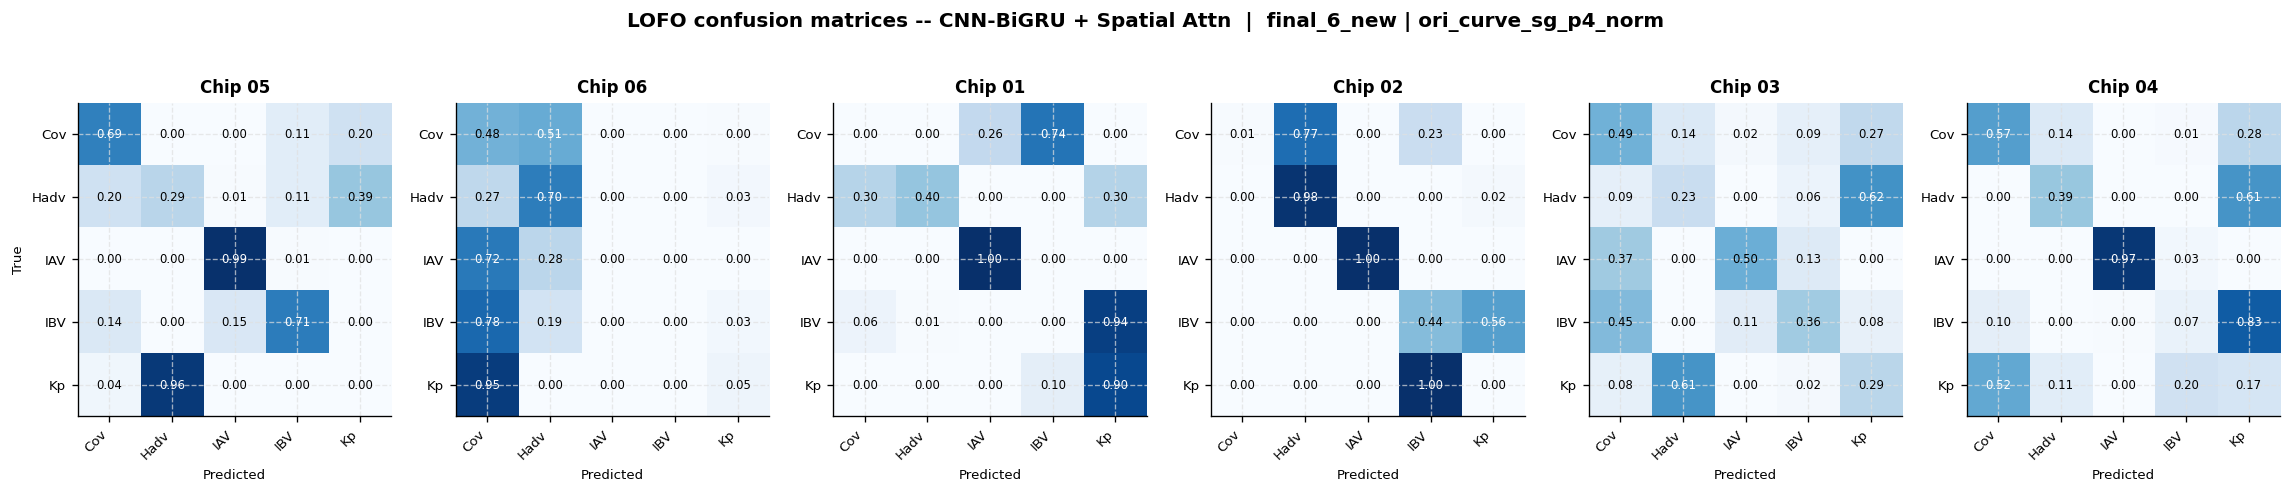

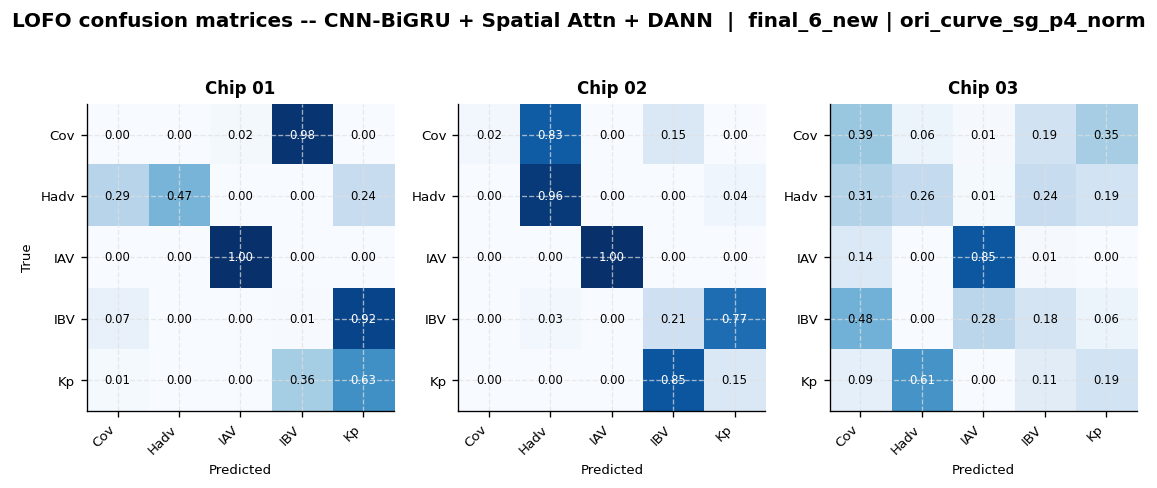

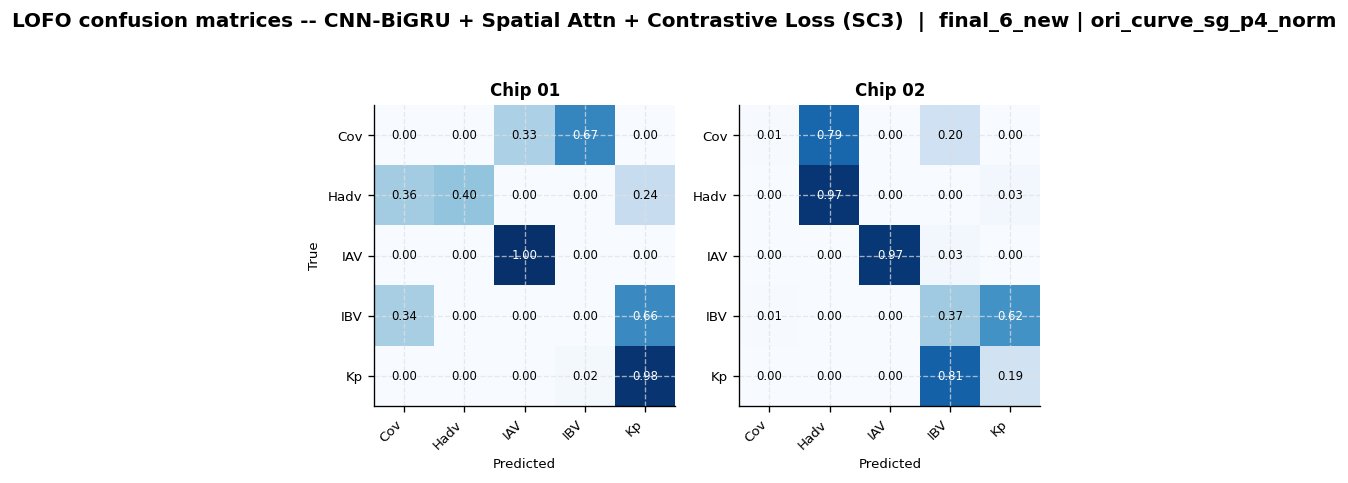

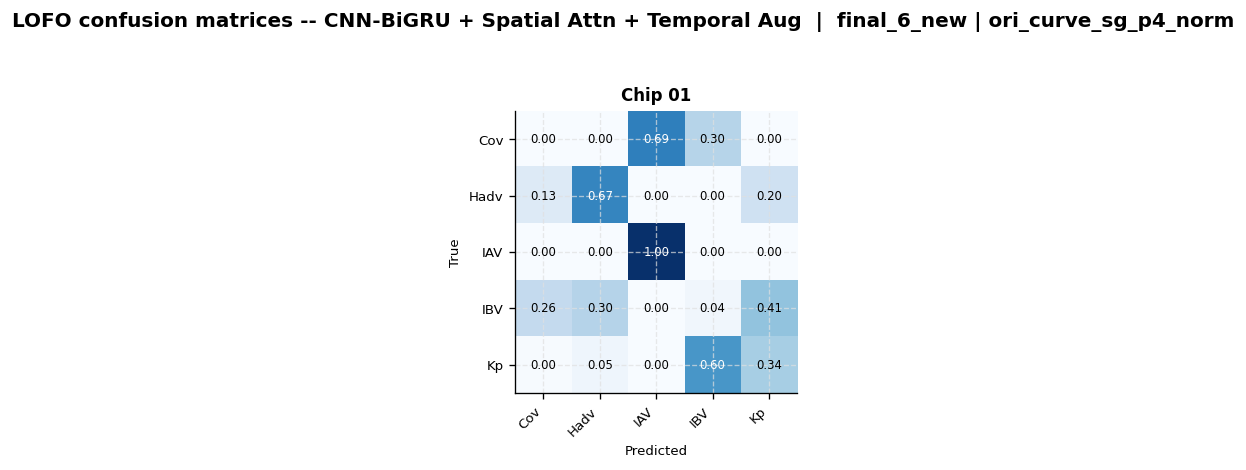

In [26]:
def plot_lofo_confusion_matrices(lofo_results, group_name, curve_type, model,
                                 filter_name=LOFO_FILTER, normalize=True,
                                 figsize_per_cell=(3.2, 3.6)):
    preds_key = config.MODEL_KEY_MAP.get(model, (None,))[0]
    if preds_key is None:
        print(f"[!] Unknown model key: {model!r}")
        return

    fold_labels = sorted(k for k in lofo_results if k.startswith("lofo_"))
    panels = []
    for fold_label in fold_labels:
        fold_entry = lofo_results[fold_label]
        res_entry = fold_entry.get(filter_name)
        class_names = fold_entry.get("class_names")
        if res_entry is None or class_names is None or preds_key not in res_entry:
            continue
        y_true = np.concatenate(res_entry["y_trues_"])
        y_pred = np.concatenate(res_entry[preds_key])
        cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
        with np.errstate(invalid='ignore', divide='ignore'):
            cm_disp = cm / cm.sum(axis=1, keepdims=True) if normalize else cm
        panels.append((fold_label.replace("lofo_", ""), class_names, cm, cm_disp))

    if not panels:
        print(f"[!] No LOFO results for model {model!r} ({group_name}/{curve_type}/{filter_name}).")
        return

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]), squeeze=False)
    axes = axes[0]
    for ax, (held_out, class_names, cm, cm_disp) in zip(axes, panels):
        ax.imshow(cm_disp, cmap='Blues', vmin=0, vmax=1 if normalize else None)
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = cm_disp[i, j]
                text = f"{val:.2f}" if normalize else f"{cm[i, j]:,}"
                color = 'white' if (not np.isnan(val) and val > 0.5) else 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=7, color=color)
        ax.set_title(short_name(held_out), fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
    axes[0].set_ylabel('True', fontsize=8)
    fig.suptitle(f"LOFO confusion matrices -- {FAMILY_LABELS.get(model, model).replace(chr(10), ' ')}  |  "
                f"{group_name} | {curve_type}", fontsize=12, fontweight='bold', y=1.06)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


LOFO_CM_CURVE_TYPE = "ori_curve_sg_p4_norm"
for _cm_group in LOFO_GROUP_NAMES:
    _cm_lofo_results = load_lofo_results(_cm_group, LOFO_CM_CURVE_TYPE)
    for _cm_model in RQ3_2_BASE_MODELS:
        plot_lofo_confusion_matrices(_cm_lofo_results, _cm_group, LOFO_CM_CURVE_TYPE, _cm_model)


### LOFO confusion matrices -- PC-recenter variants

Same layout, but for each of the 4 `*_pc_recenter` variants (`PC_RECENTER_BASES`).
These don't have a cached `y_preds_AC_*` array (their accuracy comes from a separate
`predict_new_chip(..., pc_recenter=True)` call, not the main training loop), so
`lofo_pc_recenter_accuracy` now also computes and caches the confusion matrix
(`cm_base`/`cm_recenter`) alongside the accuracy it already returned -- reusing the
same `pc_recenter_sweep_cache.joblib` `load_lofo_accuracy` already warmed earlier in
this notebook. Shows the **recentered** confusion matrix (the whole point of this
variant); pre-existing cache entries from before this change self-heal with one
recompute (missing `cm_base` is treated as a cache miss).


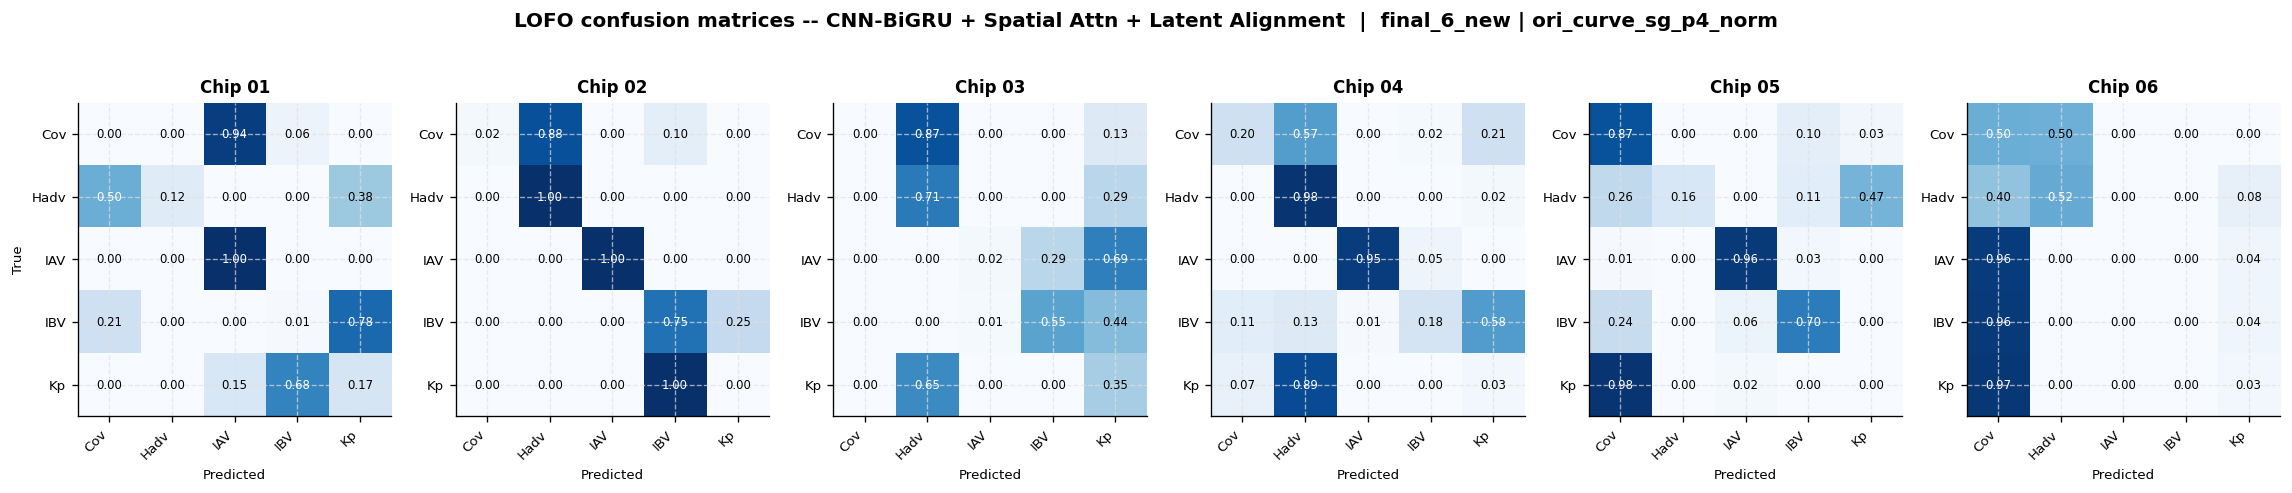

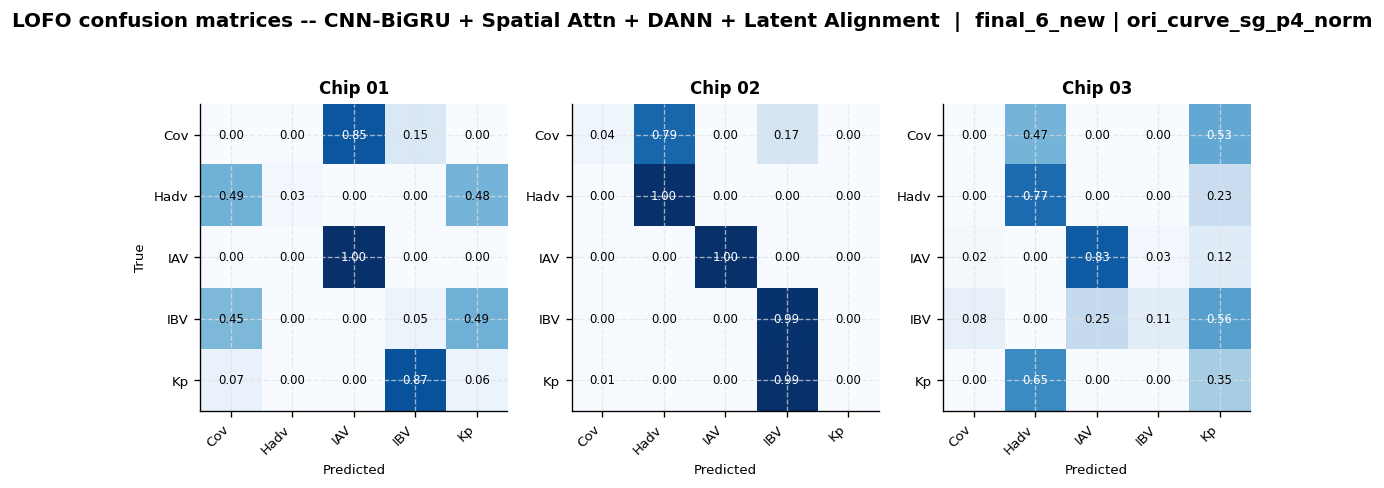

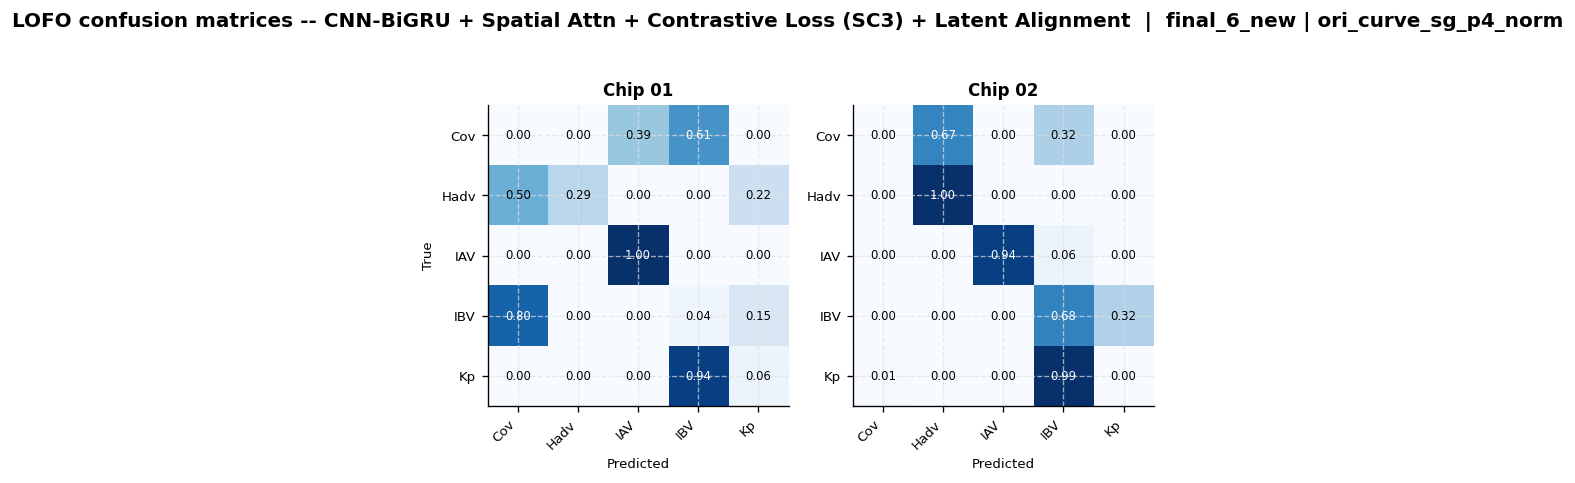

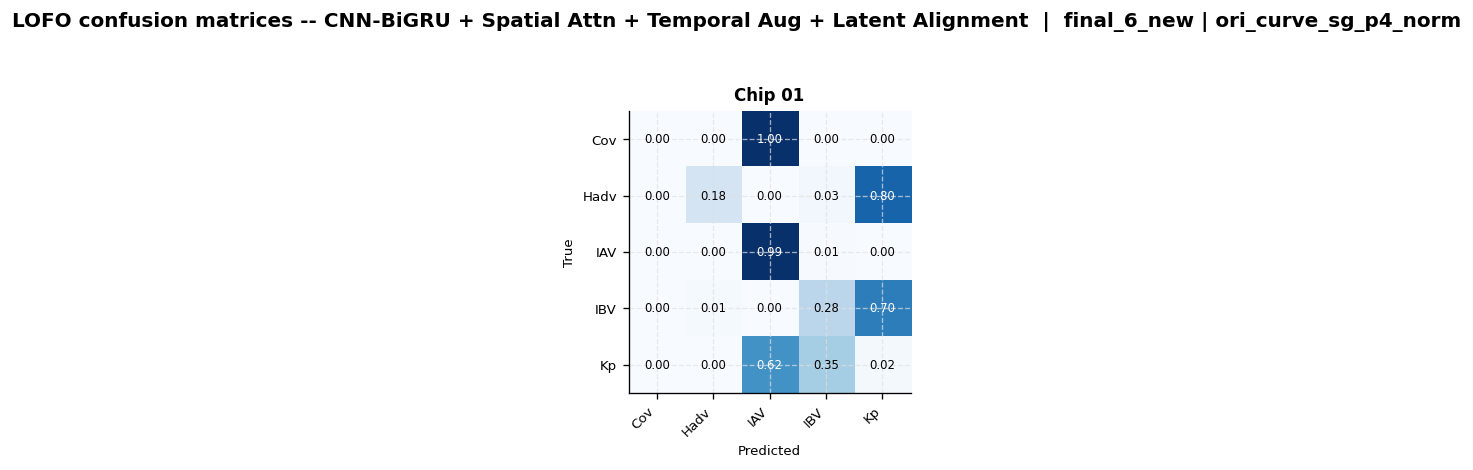

In [27]:
def plot_lofo_confusion_matrices_pc_recenter(group_name, curve_type, base_model, exp_paths_all,
                                              pc_cache, lofo_results, train_center_frac=LOFO_FRAC,
                                              normalize=True, figsize_per_cell=(3.2, 3.6)):
    panels = []
    for chip_path in exp_paths_all:
        chip_name = chip_path.name
        fold_entry = lofo_results.get(f"lofo_{chip_name}", {})
        class_names = fold_entry.get("class_names")
        if class_names is None:
            continue
        result = lofo_pc_recenter_accuracy(group_name, curve_type, base_model, chip_path,
                                           exp_paths_all, class_names, pc_cache,
                                           train_center_frac=train_center_frac)
        if result is None or result.get("cm_recenter") is None:
            continue
        cm = result["cm_recenter"]
        with np.errstate(invalid='ignore', divide='ignore'):
            cm_disp = cm / cm.sum(axis=1, keepdims=True) if normalize else cm
        panels.append((chip_name, result["class_names"], cm, cm_disp))

    if not panels:
        print(f"[!] No PC-recenter LOFO results for base model {base_model!r} ({group_name}/{curve_type}).")
        return

    n = len(panels)
    fig, axes = plt.subplots(1, n, figsize=(figsize_per_cell[0] * n, figsize_per_cell[1]), squeeze=False)
    axes = axes[0]
    for ax, (held_out, class_names, cm, cm_disp) in zip(axes, panels):
        ax.imshow(cm_disp, cmap='Blues', vmin=0, vmax=1 if normalize else None)
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=8)
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names, fontsize=8)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = cm_disp[i, j]
                text = f"{val:.2f}" if normalize else f"{cm[i, j]:,}"
                color = 'white' if (not np.isnan(val) and val > 0.5) else 'black'
                ax.text(j, i, text, ha='center', va='center', fontsize=7, color=color)
        ax.set_title(short_name(held_out), fontsize=10, fontweight='bold')
        ax.set_xlabel('Predicted', fontsize=8)
    axes[0].set_ylabel('True', fontsize=8)
    model_key = f"{base_model}_pc_recenter"
    fig.suptitle(f"LOFO confusion matrices -- {FAMILY_LABELS.get(model_key, model_key).replace(chr(10), ' ')}  |  "
                f"{group_name} | {curve_type}", fontsize=12, fontweight='bold', y=1.06)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


for _cm_group in LOFO_GROUP_NAMES:
    _cm_exp_paths_all = [Path(EXP_FOLDER, name) for name in config.CROSS_DATASET_GROUPS[_cm_group]]
    _cm_pc_cache = load_pc_cache(_cm_group)
    _cm_pc_lofo_results = load_lofo_results(_cm_group, LOFO_CM_CURVE_TYPE)
    for _cm_base_model in PC_RECENTER_BASES:
        plot_lofo_confusion_matrices_pc_recenter(_cm_group, LOFO_CM_CURVE_TYPE, _cm_base_model,
                                                 _cm_exp_paths_all, _cm_pc_cache, _cm_pc_lofo_results)


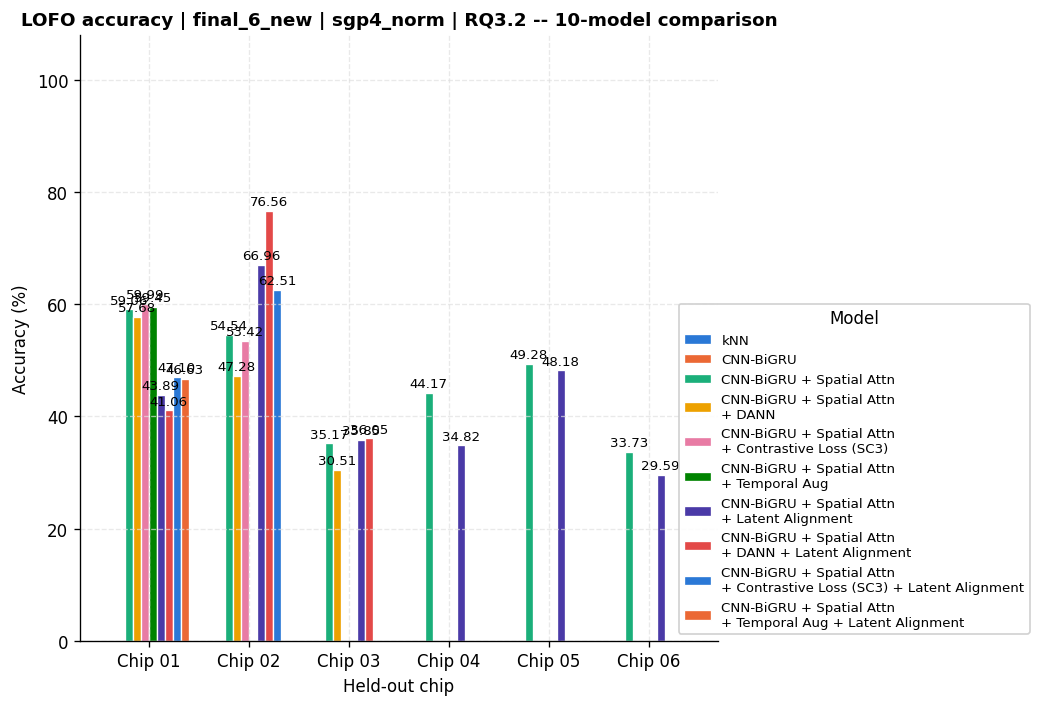

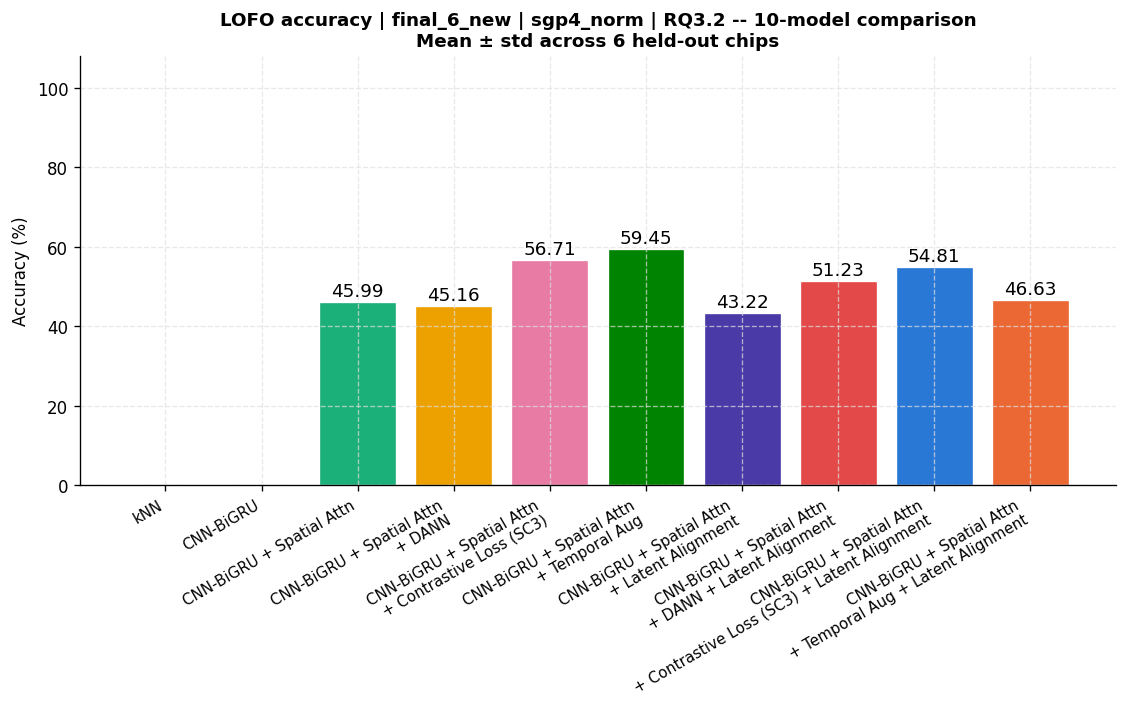

In [28]:
%matplotlib inline

# selected_held_outs = ['DDM_01']
selected_held_outs = []
if selected_held_outs:
    lofo_df_filtered = lofo_df[lofo_df['fold'].isin(selected_held_outs)].copy()
else:
    lofo_df_filtered = lofo_df.copy()

lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['curve_type'] == 'sgp4_norm']
lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['group'].isin(LOFO_GROUP_NAMES)]
# lofo_df_filtered = lofo_df_filtered[lofo_df_filtered['model'].isin(['cnn_gru_dual', 'cnn_gru_dual_attn_recon', 'cnn_gru_dual_attn_recon_pc_recenter'])]

for (group_name, curve_type), sub in lofo_df_filtered.groupby(['group', 'curve_type']):
    fold_labels = sorted(sub.fold.unique())
    for comparison, label in [(RQ3_2_COMPARISON, "RQ3.2 -- 10-model comparison")]:
        comp_sub = sub[sub.model.isin(comparison)]
        if comp_sub.empty:
            continue
        stats = plot_grouped_bar_by_model(
            comp_sub, x_col='fold', x_order=fold_labels, models=comparison, model_labels=FAMILY_LABELS,
            xlabel='Held-out chip', title=f'LOFO accuracy | {group_name} | {curve_type} | {label}',
            plot_fold=True, plot_summary=True, show_std=False,
        )
        # print(f"\nMean ± std across held-out chips ({group_name} | {curve_type} | {label}):")
        # print(stats.round(2))
    print("="*70)
